# Lab 5 — Spatial Filtering: Smoothing and Sharpening



---
## Theory — What is spatial filtering?

**Spatial filtering** means modifying a pixel's value based on the neighboring pixels. You slide a small matrix called a **kernel** (or mask/filter) across the image and at each position perform a mathematical operation.

<img src="https://drive.google.com/uc?export=view&id=14h_QV-crbe3ab3fcmF9d5db6eYThNFR7" width="550">

Different filters achieve different effects:

- **Low-pass** filters: make the image becomes blurrier.
- **High-pass** filters: make the image becomes sharper.

<img src="https://drive.google.com/uc?export=view&id=1v18SbrKW9XotZH2sJrW6E4U1Tc2O6DUs" width="850">

<img src="https://drive.google.com/uc?export=view&id=1DOoD9u8E-6reTMpE6oDPP6wdYGhlunGh" width="500">



<img src="https://drive.google.com/uc?export=view&id=1umT-MHWPjtNDjUf2SiS3F0BfM2v4Fg9S" width="370">


## Setup — Import libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

%matplotlib inline

In [2]:
plt.rcParams['figure.dpi'] = 70  

## Task 1 — Unsharp Masking

**Unsharp masking** is a classic sharpening trick. Despite its confusing name, the output is a *sharper* image. The idea:

1. Blur the image → this is the "unsharp" version.
2. Subtract blurred from original.
3. Add that mask back to the original, multiplied by an `amount` → edges become sharper.


**Parameters:**
- `sigma` — how strong the blur is.
- `amount` — how much sharpening to apply.

/opt/anaconda3/envs/p1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


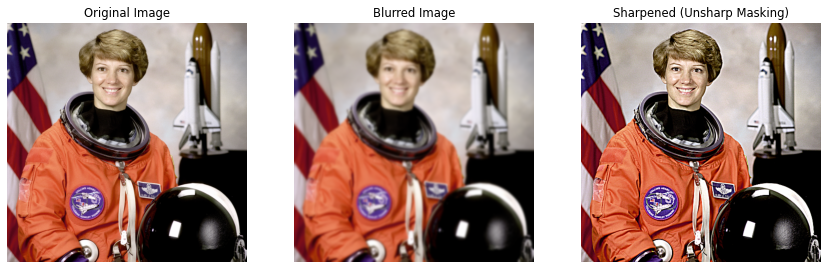

In [3]:
image = data.astronaut()

# Gaussian sigma (blur strength)
sigma = 2

# Sharpening strength
amount = 1.5

# Convert image to float32 for processing
image_float = image.astype(np.float32) / 255.0

# Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

# Perform Unsharp Masking
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

# Plot original, blurred, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image);      ax[0].set_title("Original Image");              ax[0].axis("off")
ax[1].imshow(blurred);    ax[1].set_title("Blurred Image");               ax[1].axis("off")
ax[2].imshow(sharpened);  ax[2].set_title("Sharpened (Unsharp Masking)"); ax[2].axis("off")
plt.show()

---


## Assessment Task 1 — 7×7 Box Filter

A **box filter** is the simplest smoothing filter: every pixel is replaced by the **average** of the pixels in a square window around it. Every weight is equal — like a blurred "box" of influence.

A 7×7 box kernel looks like:

$$K = \frac{1}{49}\begin{bmatrix} 1 & 1 & \cdots & 1 \\ 1 & 1 & \cdots & 1 \\ \vdots & & \ddots & \vdots \\ 1 & 1 & \cdots & 1 \end{bmatrix}$$

All 49 entries are `1/49` so the weights sum to 1 (preserves average brightness).

**Effect:** Blurs the image and reduces noise. Downside: also blurs edges and produces slightly "blocky" results because of the equal weights.

Steps:
1) Build the kernel manually.
2) Apply convolution. `cv2.filter2D` is the general-purpose convolution function. It takes any kernel you give it and slides it across the image.


## Assessment Task 2 — 5×5 and 21×21 Gaussian Filters

The **Gaussian filter** is a smarter blur than the box filter. Instead of giving all pixels equal weight, it weights **nearby pixels more** than far ones, following a 2D Gaussian (bell-curve) distribution:

$$G(x,y) = \frac{1}{2\pi\sigma^2}\, e^{-\frac{x^2 + y^2}{2\sigma^2}}$$

A 5×5 Gaussian kernel (small blur):

$$\frac{1}{256}\begin{bmatrix}1 & 4 & 6 & 4 & 1\\4 & 16 & 24 & 16 & 4\\6 & 24 & 36 & 24 & 6\\4 & 16 & 24 & 16 & 4\\1 & 4 & 6 & 4 & 1\end{bmatrix}$$

**Why prefer Gaussian over box?**
- Smoother, more natural-looking blur (no blocky artifacts)
- Preserves edges slightly better for the same blur strength
- It's the mathematically optimal tradeoff between blurring and detail preservation

**Kernel size matters:**
- Small (e.g. 5×5) → gentle blur, subtle noise reduction
- Large (e.g. 21×21) → heavy blur, washes out fine detail

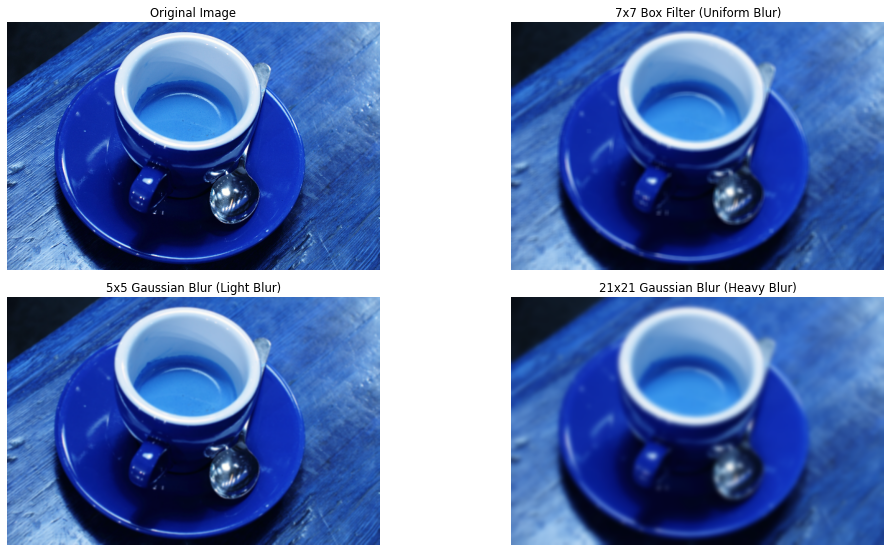

In [4]:
image = data.coffee()
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 1. Task 1: 7x7 Box Filter (Uniform Blur)
box_kernel = np.ones((7, 7), np.float32) / 49
box_7x7 = cv2.filter2D(image_rgb, -1, box_kernel)

# 2. Task 2: 5x5 and 21x21 Gaussian Filters
gauss_5x5 = cv2.GaussianBlur(image_rgb, (5, 5), 0)
gauss_21x21 = cv2.GaussianBlur(image_rgb, (21, 21), 0)

# 3. Plot images
plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(box_7x7)
plt.title('7x7 Box Filter (Uniform Blur)')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(gauss_5x5)
plt.title('5x5 Gaussian Blur (Light Blur)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(gauss_21x21)
plt.title('21x21 Gaussian Blur (Heavy Blur)')
plt.axis('off')

plt.tight_layout()
plt.show()

## Assessment Task 3 — 3×3 Laplacian Sharpening

The **Laplacian** is a *second-order* derivative operator that responds to rapid intensity changes (edges) from any direction. A common 3×3 Laplacian kernel:

$$K = \begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix}$$

The Laplacian's raw output is **negative around bright edges and positive around dark ones**. By itself it doesn't look like an image — it looks like an edge map.

**Sharpening trick:**

$$\text{sharp} = \text{original} - \text{laplacian}$$

Subtracting the Laplacian from the original boosts edges. The result: the image looks the same, but edges pop more.

Steps (exactly as requested in the lab):
1. Read the image
2. Convert to `float32` (Laplacian can produce negatives)
3. Apply `cv2.Laplacian()`
4. Sharpen: `np.clip(image_float - laplacian, 0, 1)`
5. Plot the three images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.4941177].


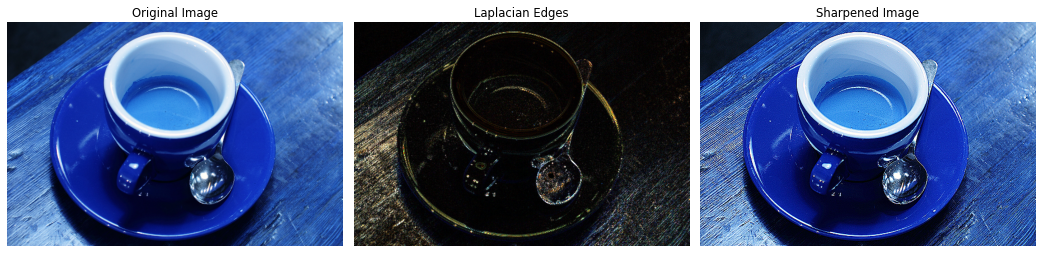

In [5]:
image = data.coffee()
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

image_float = image_rgb.astype(np.float32) / 255.0

laplacian = cv2.Laplacian(image_float, cv2.CV_32F, ksize=1)
sharpened = np.clip(image_float - laplacian, 0.0, 1.0)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_float)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
# Display
plt.imshow(np.abs(laplacian), cmap='gray')
plt.title('Laplacian Edges')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sharpened)
plt.title('Sharpened Image')
plt.axis('off')

plt.tight_layout()
plt.show()

## Q1 — Effect of Different Box Filter Sizes
Compare 3×3, 9×9, and 15×15 box filters. Bigger kernel = stronger blur = more detail lost.

## ANSWER
**As the kernel size $N$ grows, the window averages intensity values over a larger neighborhood ($N^2$ pixels). This acts as a stronger low-pass filter, removing increasingly lower spatial frequencies (edges and fine structures).**

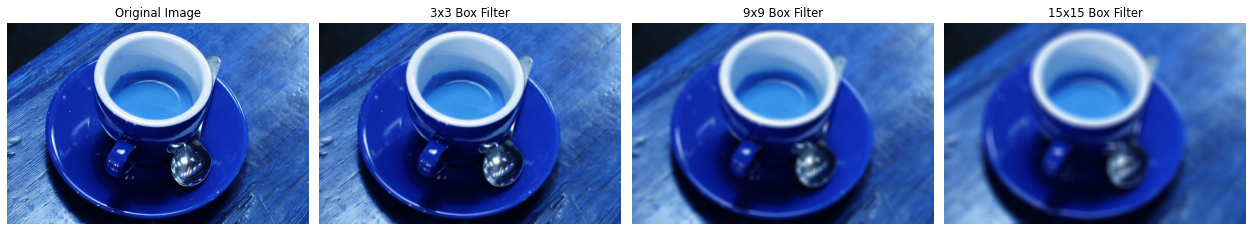

In [6]:
image = data.coffee()
if image is None:
    raise FileNotFoundError("Check image path!")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

kernel_sizes = [3, 9, 15]
filtered_images = []

for k in kernel_sizes:
    kernel = np.ones((k, k), np.float32) / (k * k)
    blurred = cv2.filter2D(image_rgb, ddepth=-1, kernel=kernel)
    filtered_images.append(blurred)

plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')

for idx, (k, blurred_img) in enumerate(zip(kernel_sizes, filtered_images), start=2):
    plt.subplot(1, 4, idx)
    plt.imshow(blurred_img)
    plt.title(f'{k}x{k} Box Filter')
    plt.axis('off')

plt.tight_layout()
plt.show()

## Q2 — Median Filter: Removing Salt-and-Pepper Noise
The **median filter** replaces each pixel with the *median* of its neighborhood — not the mean. It's the best tool for removing "salt and pepper" noise (random black and white specks), because the median ignores extreme outliers.

Compare the median filter to a Gaussian blur on the same noisy image — Gaussian smears the specks, median removes them cleanly.

## ANSWER
**Gaussian blur averages pixels, which incorporates extreme noise values ($0$ and $255$) into the result and spreads them into blurry smudges. The median filter ranks neighboring pixels and picks the middle value, completely discarding those extreme outliers while preserving sharp edges.**

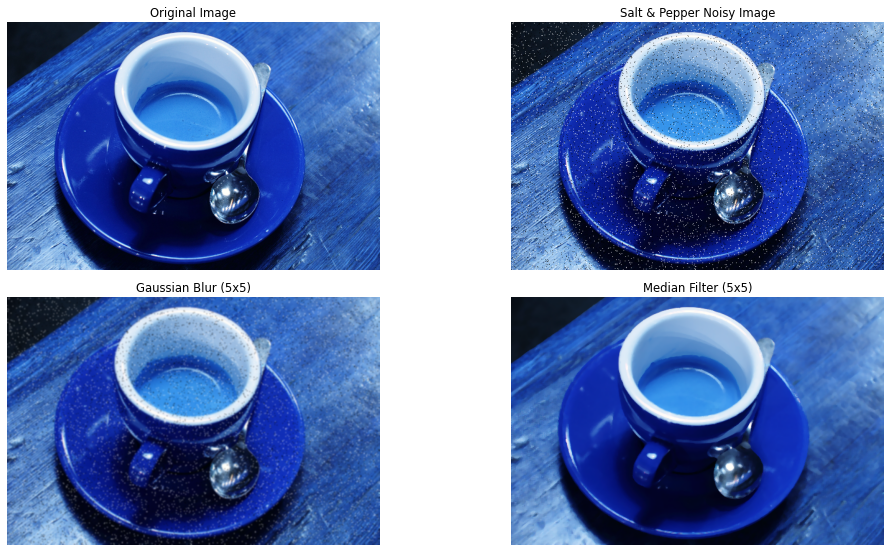

In [7]:
image = data.coffee()
if image is None:
    raise FileNotFoundError("Check image path!")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

noisy_image = image_rgb.copy()
prob = 0.05  
salt_mask = np.random.rand(*image_rgb.shape[:2]) < (prob / 2)
noisy_image[salt_mask] = 255

pepper_mask = np.random.rand(*image_rgb.shape[:2]) < (prob / 2)
noisy_image[pepper_mask] = 0

gaussian_filtered = cv2.GaussianBlur(noisy_image, (5, 5), 0)

median_filtered = cv2.medianBlur(noisy_image, 5)

plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(noisy_image)
plt.title('Salt & Pepper Noisy Image')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(gaussian_filtered)
plt.title('Gaussian Blur (5x5)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(median_filtered)
plt.title('Median Filter (5x5)')
plt.axis('off')

plt.tight_layout()
plt.show()

## Q3 — Bilateral Filter: Blurring While Keeping Edges Sharp
A normal Gaussian blur smooths everything — including edges. The **bilateral filter** is smarter: it blurs pixels only if they are close in *space* AND similar in *intensity*. Result: flat areas get smoothed, but edges stay crisp. Used in "beauty" filters, cartoon effects, and denoising.

## ANSWER
**While a Gaussian filter considers only spatial distance, the Bilateral filter combines two separate Gaussian kernels; Spatial Kernel and Range/Color Kernel, Across a sharp edge, the spatial distance may be small, but the color difference is huge. The range kernel drops to near zero, preventing the filter from averaging pixels across the boundary and leaving the edge sharp.**

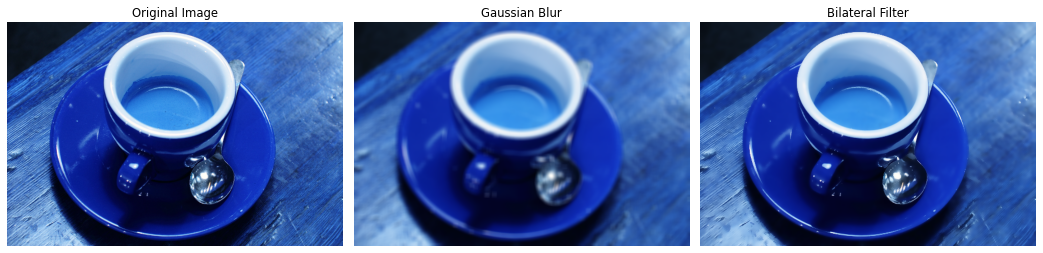

In [8]:
image = data.coffee()
if image is None:
    raise FileNotFoundError("Check image path!")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

gaussian_blur = cv2.GaussianBlur(image_rgb, (9, 9), sigmaX=75)
bilateral_blur = cv2.bilateralFilter(image_rgb, d=9, sigmaColor=75, sigmaSpace=75)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gaussian_blur)
plt.title('Gaussian Blur')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(bilateral_blur)
plt.title('Bilateral Filter')
plt.axis('off')

plt.tight_layout()
plt.show()

---
## Summary Table

| Filter | Type | Effect | OpenCV function |
|---|---|---|---|
| **Box** | Smoothing (low-pass) | Simple average blur | `cv2.blur` or `cv2.filter2D` |
| **Gaussian** | Smoothing (low-pass) | Bell-curve weighted blur, smoother | `cv2.GaussianBlur` |
| **Median** | Smoothing (non-linear) | Removes salt-and-pepper noise | `cv2.medianBlur` |
| **Bilateral** | Smoothing (edge-preserving) | Blurs flat areas, keeps edges | `cv2.bilateralFilter` |
| **Laplacian** | Sharpening (high-pass) | Second-derivative edge enhance | `cv2.Laplacian` |
| **Unsharp mask** | Sharpening (combo) | Original + (original − blurred) | Custom (using `cv2.GaussianBlur`) |
| **Custom kernel** | Anything | Any effect you design | `cv2.filter2D` |

**Two rules to remember:**
1. For *smoothing* → use a low-pass filter (Box, Gaussian, Median, Bilateral).
2. For *sharpening* → amplify the high-frequency content (Laplacian, Unsharp mask, custom kernel with negative surround).

**End of notebook.**